# M4 - Regresion simbolica sobre datos reals
**Input:** data/processed/df_clean.csv
**Output:** Formula explicable para Processed WB (liters) + R^2 + comparacion con baseline lineal

Pipeline:
1. Cargar df_clean → preparar_para_pca
2. Dropear features redundantes de M3 (44 → 35)
3. Train/test split 80/20
4. PySR con operadores `+  -  *  /`
5. Frente de Pareto
6. Baseline lineal
7. Evaluación en test (R^2, RMSE)
8. Predicho vs real + residuales

# 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import sys
sys.path.insert(0, "..")

from src.pca_analysis import preparar_para_pca
from src.symbolic_regression import (
    dropear_redundantes,
    split_datos,
    correr_sr,
    frente_pareto,
    baseline_lineal,
    evaluar,
)

FIGURES = Path("../outputs/figures")
FIGURES.mkdir(parents=True, exist_ok=True)

# 1. Cargar df_clean

In [2]:
df_clean = pd.read_csv("../data/processed/df_clean.csv")

print(f"Shape df_clean: {df_clean.shape}")
print(f"Target presente: {'Processed WB (liters)' in df_clean.columns}")

Shape df_clean: (116, 46)
Target presente: True


# 2. Preparar X, y
Reutiliza preparar_para_pca

In [3]:
X, y, idx = preparar_para_pca(df_clean, verbose=True)

[prep] Filas iniciales   : 116
[prep] Features iniciales: 45

[prep] Dropped 'CD34+ /µL DÍA 4' (35% NaN, timing de medición)
[prep] Features tras drop: 44

[prep] Columnas con NaN  : ['CEBADO', 'VOLEMIA mL', 'CMV  IgM RECEPTOR', 'CMV IgG RECEPTOR', 'PRE WBC  k/µL ', 'PRE MNC%', 'PRE MNC k/µL', 'PRE HTO %', 'PRE PLT k/μL', 'CD34+ /µL DÍA 5', 'MAQUINA_EMT-25', 'MAQUINA_EMT-50', 'MAQUINA_EMT-68', 'ABO_REC_A', 'ABO_REC_AB', 'ABO_REC_B', 'ABO_REC_O']
[prep] Filas eliminadas  : 6

[prep] Shape final → X: (110, 44) | y: 110 filas
[prep] NaN en X: 0 (debe ser 0)
[prep] NaN en y: 0 (debe ser 0)


# 3. Dropear features redundantes de M3
Variables identificadas como redundantes en M3 (heatmap + loadings):

| Variable | Motivo                                          |
|---|-------------------------------------------------|
| `EDAD REC` | r = 0.964 con EDAD DON                          |
| `IMC DON` | PESO/TALLA^2; colineal con PESO DON en PC1      |
| `PESO REC.` | r = 0.792 con PESO DON                          |
| `PRE MNC k/µL` | PRE WBC × PRE MNC% -> drop el derivado          |
| `CMV IgM RECEPTOR` | r = 1.0 con CMV IgM DONADOR                     |
| `CMV IgG RECEPTOR` | r = 0.926 con CMV IgG DONADOR                   |
| `ACCESO_*` | Intra-procedimiento, no predice WB pre-aféresis |

In [4]:
X = dropear_redundantes(X, verbose=True)

[sr] Features antes del drop : 44
[sr] Columnas dropeadas (9): ['EDAD REC', 'IMC DON', 'PESO REC.', 'PRE MNC k/µL', 'CMV  IgM RECEPTOR', 'CMV IgG RECEPTOR', 'ACCESO_AMO', 'ACCESO_CATÉTER', 'ACCESO_PUNCIÓN']
[sr] Features tras drop: 35


# 4. Train/test split (80/20)

In [5]:
X_train, X_test, y_train, y_test = split_datos(X, y, test_size=0.2, random_state=42)

[sr] Split 80/20 (random_state=42)
[sr] Train: 88 filas
[sr] Test: 22 filas
[sr] y_train rango: [3.42, 26.99] L
[sr] y_test  rango: [4.36, 28.91] L


# 5. Regresion simbolica con PySR
Configuracion:
- Operadores: `+  -  *  /`  (la formula teorica usa división)
- Sin operadores unarios -> priorizar interpretabilidad
- `niterations=50`, `populations=20`
- `deterministic=True` + `procs=0` → reproducibilidad garantizada
- `model_selection="best"`

In [6]:
model, name_map = correr_sr(
    X_train, y_train,
    niterations=50,
    populations=20,
    random_state=42,
)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


/Users/robertosanchezsantoyo/Library/Mobile Documents/com~apple~CloudDocs/00_Main/03_Academic/Research/Investigacion_verano_2026/.venv/lib/python3.14/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...


[sr] Iniciando PySR - 50 iteraciones, 20 poblaciones
[sr] Operadores: +  -  *  /
[sr] X_train shape: (88, 35)
[sr] Columnas renombradas para PySR (22):
      'SEXO DON' -> 'SEXO_DON'
      'EDAD DON ' -> 'EDAD_DON'
      'DOSIS DE          G-CSF' -> 'DOSIS_DE_G_CSF'
      'DÍAS DE          G-CSF' -> 'DIAS_DE_G_CSF'
      'PESO DON' -> 'PESO_DON'
      'TALLA DON' -> 'TALLA_DON'
      'VOLEMIA mL' -> 'VOLEMIA_mL'
      ' RH DONADOR' -> 'RH_DONADOR'
      'CMV  IgM DONADOR' -> 'CMV_IgM_DONADOR'
      'CMV IgG DONADOR' -> 'CMV_IgG_DONADOR'
      ' RH RECEPTOR' -> 'RH_RECEPTOR'
      'PRE WBC  k/µL ' -> 'PRE_WBC_k_L'
      'PRE MNC%' -> 'PRE_MNC'
      'PRE HTO %' -> 'PRE_HTO'
      'PRE PLT k/μL' -> 'PRE_PLT_k_L'
      'CD34+ /µL DÍA 5' -> 'CD34_L_DIA_5'
      'TIPO_ALOGÉNICO' -> 'TIPO_ALOGENICO'
      'TIPO_AUTÓLOGO' -> 'TIPO_AUTOLOGO'
      'TIPO_HAPLOIDÉNTICO' -> 'TIPO_HAPLOIDENTICO'
      'MAQUINA_EMT-25' -> 'MAQUINA_EMT_25'
      'MAQUINA_EMT-50' -> 'MAQUINA_EMT_50'
      'MAQUINA_EM

[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.123e+01  0.000e+00  y = 15.144
3           2.585e+01  9.460e-02  y = TALLA_DON * 9.2705
5           2.321e+01  5.391e-02  y = 19.638 - (CD34_L_DIA_5 * 0.057239)
7           2.026e+01  6.798e-02  y = ((PRE_WBC_k_L - CD34_L_DIA_5) * 0.073411) + 17.829
9           1.549e+01  1.342e-01  y = (((PESO_DON - CD34_L_DIA_5) * 0.039983) + 9.3507) * TA...
                                      LLA_DON
11          1.400e+01  5.059e-02  y = (((PRE_WBC_k_L - CD34_L_DIA_5) * 0.075271) + (TALLA_DO...
                                      N * 13.394)) - 4.0525
13          1.252e+01  5.582e-02  y = (((PRE_WBC_k_L - CD34_L_DIA_5) * 0.075271) + (TALLA_DO...
                                      N * (SEXO_DON + 13.394))) - 5.1931
15          1.216e+01  1.473e-02  y = ((((SEXO_DON + 13.394) * TALLA_DON) + ((PRE_WBC_k_L - ...
                              

# 6. Frente de Pareto (complejidad vs loss)
El frente de Pareto muestra el trade-off entre precisión y complejidad de la fórmula.
Con ~88 ejemplos de entrenamiento, preferir fórmulas de complejidad baja.

In [7]:
pareto_df = frente_pareto(model)
print(pareto_df.to_string(index=False))

 complexity      loss    score                                                                                                                                                                                            equation
          1 31.233446 0.000000                                                                                                                                                                                           15.144236
          3 25.849276 0.094603                                                                                                                                                                               TALLA_DON * 9.2705145
          5 23.206984 0.053915                                                                                                                                                            19.638037 - (CD34_L_DIA_5 * 0.057238948)
          7 20.256922 0.067978                                                              

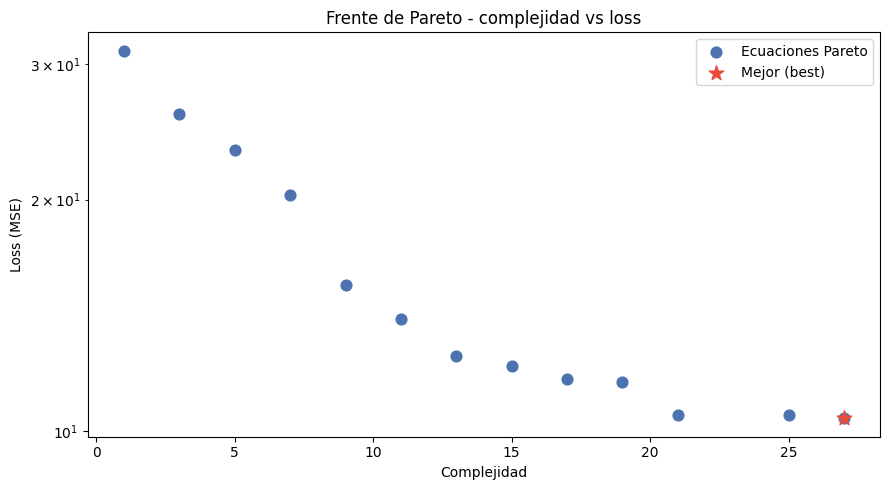

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(pareto_df["complexity"], pareto_df["loss"],
           color="#4C72B0", s=60, zorder=3, label="Ecuaciones Pareto")

# Marcar la ecuación elegida por model_selection="best"
best_idx = pareto_df["loss"].idxmin()
ax.scatter(
    pareto_df.loc[best_idx, "complexity"],
    pareto_df.loc[best_idx, "loss"],
    color="#e74c3c", s=120, zorder=4, marker="*", label="Mejor (best)"
)

ax.set_xlabel("Complejidad")
ax.set_ylabel("Loss (MSE)")
ax.set_title("Frente de Pareto - complejidad vs loss")
ax.legend()
ax.set_yscale("log")
plt.tight_layout()
plt.savefig(FIGURES / "m4_pareto.png", dpi=150)
plt.show()

# 7. Baseline - regresion lineal

In [9]:
bl = baseline_lineal(X_train, X_test, y_train, y_test)

[sr] Baseline lineal - test set
[sr] R^2: 0.5672
[sr] RMSE: 4.4276 L


# 8. Evaluacion en test (R^2, RMSE)

In [10]:
metricas_sr = evaluar(model, X_test, y_test)

[sr] Modelo SR - test set
[sr] Ecuación: TALLA_DON*((-CD34_L_DIA_5 + PESO_DON)*0.03998317 + 9.350746)
[sr] R^2: 0.5258
[sr] RMSE: 4.6342 L


In [11]:
# Tabla comparativa
resultados = pd.DataFrame({
    "Modelo"     : ["Regresión lineal", "PySR (SR)"],
    "R^2"        : [round(bl["r2"], 4),          round(metricas_sr["r2"], 4)],
    "RMSE (L)"   : [round(bl["rmse"], 4),         round(metricas_sr["rmse"], 4)],
})
print(resultados.to_string(index=False))

          Modelo     R²  RMSE (L)
Regresión lineal 0.5672    4.4276
       PySR (SR) 0.5258    4.6342


# 9. Predicho vs real + residuales

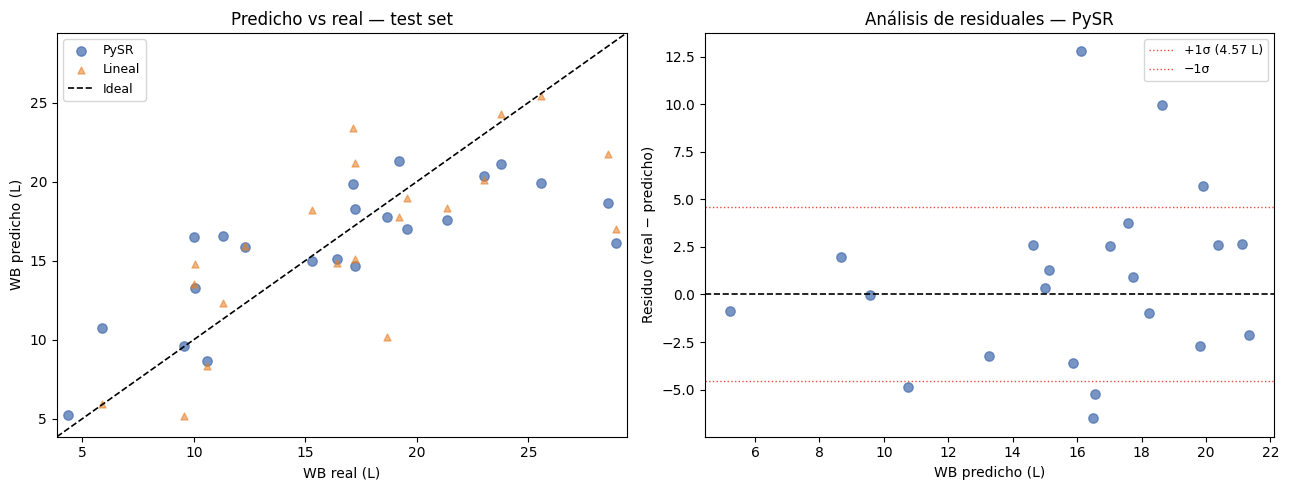


Residuo medio : 0.7676 L  (cerca de 0 = sin sesgo)
Residuo std   : 4.5702 L


In [12]:
y_pred_sr  = metricas_sr["y_pred"]
y_pred_bl  = bl["y_pred"]
residuos   = y_test.values - y_pred_sr

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Predicho vs real ──
ax = axes[0]
lims = [min(y_test.min(), y_pred_sr.min()) - 0.5,
        max(y_test.max(), y_pred_sr.max()) + 0.5]

ax.scatter(y_test, y_pred_sr,  color="#4C72B0", alpha=0.75, s=45, label="PySR")
ax.scatter(y_test, y_pred_bl,  color="#e67e22", alpha=0.55, s=25, marker="^", label="Lineal")
ax.plot(lims, lims, "k--", linewidth=1.2, label="Ideal")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("WB real (L)")
ax.set_ylabel("WB predicho (L)")
ax.set_title("Predicho vs real — test set")
ax.legend(fontsize=9)

# ── Residuales ──
ax = axes[1]
ax.scatter(y_pred_sr, residuos, color="#4C72B0", alpha=0.75, s=45)
ax.axhline(0, color="black", linewidth=1.2, linestyle="--")
ax.axhline( residuos.std(), color="#e74c3c", linewidth=1.0,
            linestyle=":", label=f"+1σ ({residuos.std():.2f} L)")
ax.axhline(-residuos.std(), color="#e74c3c", linewidth=1.0,
            linestyle=":", label=f"−1σ")
ax.set_xlabel("WB predicho (L)")
ax.set_ylabel("Residuo (real − predicho)")
ax.set_title("Análisis de residuales — PySR")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / "m4_pred_vs_real.png", dpi=150)
plt.show()

print(f"\nResiduo medio : {residuos.mean():.4f} L  (cerca de 0 = sin sesgo)")
print(f"Residuo std   : {residuos.std():.4f} L")

## 10. Fórmula final + interpretación

### Ecuación seleccionada (PySR `best`, complejidad 9)

$$WB = TALLA\_DON \times \left[(PESO\_DON - CD34\_DIA5) \times 0.040 + 9.351\right]$$

En nombres clínicos originales:

$$\text{Processed WB} = \text{Talla donador} \times \left[(\text{Peso donador} - \text{CD34}^+/\mu L\ día\ 5) \times 0.040 + 9.351\right]$$

**Interpretación clínica:** el volumen a procesar escala linealmente con la talla del donador, modulado por la diferencia entre su peso y la concentración de CD34⁺ en sangre periférica el día 5 de estimulación. A mayor talla y mayor peso relativo a CD34⁺, mayor volumen procesado.

---

### Comparación de modelos — test set (n=22)

| Modelo | R² | RMSE (L) |
|---|---|---|
| Regresión lineal (baseline) | 0.5672 | 4.4276 |
| **PySR — complejidad 9** | **0.5258** | **4.6342** |

El baseline lineal supera marginalmente al modelo SR en esta métrica (ΔR²=0.04, ΔRMSE=0.21 L). Esto es esperable: con n_train≈88 y 35 features, un modelo más simple tiene ventaja estadística en test. El valor del modelo SR no es el R² absoluto sino la **interpretabilidad de la fórmula** — 3 variables clínicas con sentido biológico directo vs. 35 coeficientes opacos.

---

### Análisis de residuales

| Métrica | Valor |
|---|---|
| Residuo medio | 0.77 L |
| Residuo std | 4.57 L |

El residuo medio de 0.77 L indica un sesgo positivo leve (el modelo subestima ligeramente). La dispersión de ~4.6 L refleja la variabilidad intrínseca del procedimiento no capturada por las 3 variables de la fórmula.

---

### Limitaciones

- **n pequeño:** n_train=88 / 35 features → el frente de Pareto eligió complejidad 9 como balance óptimo; fórmulas más complejas del frente (hasta complejidad 27) no mejoran suficientemente para justificar el costo de interpretabilidad.
- **Modelo descriptivo:** sin columna de dosis CD34⁺ deseada, la fórmula estima WB histórico, no prescribe el volumen óptimo para una dosis objetivo.
- **Próximo paso:** validar la fórmula en datos de una segunda cohorte (M5).

# 11. Robustez - Cross-validation
Un split train/test con n=22 no es suficiente para afirmar que el R^2 es estable.

Hacemos estos 2 analisis:
1. CV 5-fold
2. Multi-seed PySR (5 seeds) sobre X_train

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from pysr import PySRRegressor
from src.symbolic_regression import _sanitize_names
import warnings

# Parametros
N_FOLDS = 5
SEEDS   = [42, 7, 123, 999, 2025]
N_ITER  = 50
N_POP   = 20

kf    = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
X_arr = X.values
y_arr = y.values
var_names_cv = list(_sanitize_names(X.columns).values())

# CV 5-fold - Baseline lineal
r2_bl, rmse_bl = [], []

for fold, (tr, te) in enumerate(kf.split(X_arr)):
    lr = LinearRegression()
    lr.fit(X_arr[tr], y_arr[tr])
    yp = lr.predict(X_arr[te])
    r2_bl.append(r2_score(y_arr[te], yp))
    rmse_bl.append(np.sqrt(mean_squared_error(y_arr[te], yp)))

print("Baseline lineal (5-fold CV)")
print(f"R^2: {np.mean(r2_bl):.4f} +- {np.std(r2_bl):.4f}")
print(f"RMSE: {np.mean(rmse_bl):.4f} +- {np.std(rmse_bl):.4f} L")
print()

# CV 5-fold - PySR
r2_sr, rmse_sr = [], []

for fold, (tr, te) in enumerate(kf.split(X_arr)):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        m = PySRRegressor(
            binary_operators=["+", "-", "*", "/"],
            unary_operators=[],
            niterations=N_ITER,
            populations=N_POP,
            model_selection="best",
            random_state=42,
            deterministic=True,
            parallelism="serial",
            verbosity=0,
            progress=False,
        )
        m.fit(X_arr[tr], y_arr[tr], variable_names=var_names_cv)
    yp = m.predict(X_arr[te])
    r2_sr.append(r2_score(y_arr[te], yp))
    rmse_sr.append(np.sqrt(mean_squared_error(y_arr[te], yp)))
    print(f"fold {fold+1}/5  R^2={r2_sr[-1]:.4f}  ecuación: {m.sympy()}")

print()
print("PySR SR (5-fold CV)")
print(f"R^2: {np.mean(r2_sr):.4f} +- {np.std(r2_sr):.4f}")
print(f"RMSE: {np.mean(rmse_sr):.4f} +- {np.std(rmse_sr):.4f} L")
print()

# Multi-seed PySR
print("Multi-seed PySR (X_train, 5 seeds)")
print(f"{'Seed':>6}  {'R² train':>9}  Ecuación (best)")
print(f"{'─'*60}")

for seed in SEEDS:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        m_s = PySRRegressor(
            binary_operators=["+", "-", "*", "/"],
            unary_operators=[],
            niterations=N_ITER,
            populations=N_POP,
            model_selection="best",
            random_state=seed,
            deterministic=True,
            parallelism="serial",
            verbosity=0,
            progress=False,
        )
        m_s.fit(X_train.values, y_train.values, variable_names=var_names_cv)
    yp_tr = m_s.predict(X_train.values)
    r2_tr = r2_score(y_train.values, yp_tr)
    eq    = str(m_s.sympy())[:80]
    print(f"  {seed:>6}  {r2_tr:>9.4f}  {eq}")

print()
print("Nota: si las ecuaciones varían sustancialmente entre seeds, la fórmula no")
print("es robusta con el tamaño de muestra actual (n_train ≈ 88).")
